Question 1

In [218]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
import os

In [219]:
path = 'images/the_berry_farms_sunflower_field.jpeg'

if not os.path.exists(path):
    raise FileNotFoundError(f"Image not found at: {os.path.abspath(path)}")
  
img = cv.imread('images/the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

img_gray_norm = img_gray.astype(float) / 255.0

In [220]:
'''
cv.imshow('Grayscale Image', img_gray)
cv.waitKey(0)       # Wait until any key is pressed
cv.destroyAllWindows()
'''

"\ncv.imshow('Grayscale Image', img_gray)\ncv.waitKey(0)       # Wait until any key is pressed\ncv.destroyAllWindows()\n"

Sigma scale

In [ ]:
sigma_min = 3
sigma_max = 30
num_scales = 50
threshold = 0.2

sigma_values = np.linspace(sigma_min, sigma_max, num_scales)

log_responses = []

LoG across the scale of sigma

In [222]:
for sigma in sigma_values:
  
    blurred = ndimage.gaussian_filter(img_gray_norm, sigma)
    laplacian = ndimage.laplace(blurred)
    log_normalized = (sigma ** 2) * np.abs(laplacian)
    log_responses.append(log_normalized)


In [223]:
log_responses_array = np.array(log_responses)

print(log_responses_array.shape)  #(num_scales, height, width)


(20, 360, 360)


blobs without filtering

In [224]:

local_max = np.zeros_like(log_responses_array, dtype=bool)

for i in range(1, num_scales - 1):
    
    for y in range(1, img_gray.shape[0] - 1):
        for x in range(1, img_gray.shape[1] - 1):
            
            neighborhood = log_responses_array[i-1:i+2, y-1:y+2, x-1:x+2]
            center_value = log_responses_array[i, y, x]
            
            if center_value > threshold and center_value == neighborhood.max():
                local_max[i, y, x] = True

In [225]:

blobs = np.argwhere(local_max)
print(f"Number of blobs before filtering: {len(blobs)} )")

Number of blobs before filtering: 43 )


Filtering blobs

In [226]:
# converting to (y, x, sigma) format for filtering

blob_list = []

for scale_index, y, x in blobs:
  
    sigma = sigma_values[scale_index]
    radius = np.sqrt(2) * sigma # Radius = sqrt(2) * sigma 
    response = log_responses_array[scale_index, y, x]
    blob_list.append((y, x, sigma, radius, response))

In [227]:
blob_list.sort(key=lambda b: b[4], reverse=True)

# print(blob_list[:10])  

In [228]:
def overlaps(blob1, blob2):
    y1, x1, _, r1, _ = blob1
    y2, x2, _, r2, _ = blob2
    dist_sq = (y1 - y2)**2 + (x1 - x2)**2
    min_r = min(r1, r2)
    max_r = max(r1, r2)
    adaptive_scale = 0.5 + 0.25 * (min_r / max_r)  # less strict when blobs differ in size
    r_sum = (r1 + r2) * adaptive_scale
    return dist_sq < r_sum**2


In [229]:
filtered_blobs = []

for blob in blob_list:
    if not any(overlaps(blob, existing) for existing in filtered_blobs):
        filtered_blobs.append(blob)

In [230]:
print(f"Number of blobs after filtering: {len(filtered_blobs)}")

Number of blobs after filtering: 40


In [231]:
top_n = min(10, len(filtered_blobs))  # we select top 5 or fewer if not enough blobs


largest_blobs = sorted(filtered_blobs, key=lambda b: b[3], reverse=True)[:top_n] # sort by radius b[3]

print(top_n)





10


In [232]:
largest_blobs_array = np.array(largest_blobs)

print(largest_blobs_array[:,3])  

[18.31034402 16.30067211 10.2716564  10.2716564   8.2619845   8.2619845
  8.2619845   8.2619845   8.2619845   8.2619845 ]


In [233]:
for i, (y, x, sigma, radius, response) in enumerate(largest_blobs_array, 1):
    print(f"Circle {i}:")
    print(f"  Center: (x={x:.1f}, y={y:.1f})")
    print(f"  Sigma: {sigma:.2f}")
    print(f"  Radius: {radius:.2f} pixels")
    print(f"  LoG Response: {response:.4f}")

Circle 1:
  Center: (x=338.0, y=165.0)
  Sigma: 12.95
  Radius: 18.31 pixels
  LoG Response: 0.2476
Circle 2:
  Center: (x=293.0, y=168.0)
  Sigma: 11.53
  Radius: 16.30 pixels
  LoG Response: 0.2463
Circle 3:
  Center: (x=282.0, y=338.0)
  Sigma: 7.26
  Radius: 10.27 pixels
  LoG Response: 0.3493
Circle 4:
  Center: (x=255.0, y=174.0)
  Sigma: 7.26
  Radius: 10.27 pixels
  LoG Response: 0.2377
Circle 5:
  Center: (x=106.0, y=255.0)
  Sigma: 5.84
  Radius: 8.26 pixels
  LoG Response: 0.3632
Circle 6:
  Center: (x=178.0, y=261.0)
  Sigma: 5.84
  Radius: 8.26 pixels
  LoG Response: 0.3488
Circle 7:
  Center: (x=179.0, y=327.0)
  Sigma: 5.84
  Radius: 8.26 pixels
  LoG Response: 0.3444
Circle 8:
  Center: (x=53.0, y=174.0)
  Sigma: 5.84
  Radius: 8.26 pixels
  LoG Response: 0.3008
Circle 9:
  Center: (x=186.0, y=341.0)
  Sigma: 5.84
  Radius: 8.26 pixels
  LoG Response: 0.2596
Circle 10:
  Center: (x=222.0, y=174.0)
  Sigma: 5.84
  Radius: 8.26 pixels
  LoG Response: 0.2493


Visualization

(np.float64(-0.5), np.float64(359.5), np.float64(359.5), np.float64(-0.5))

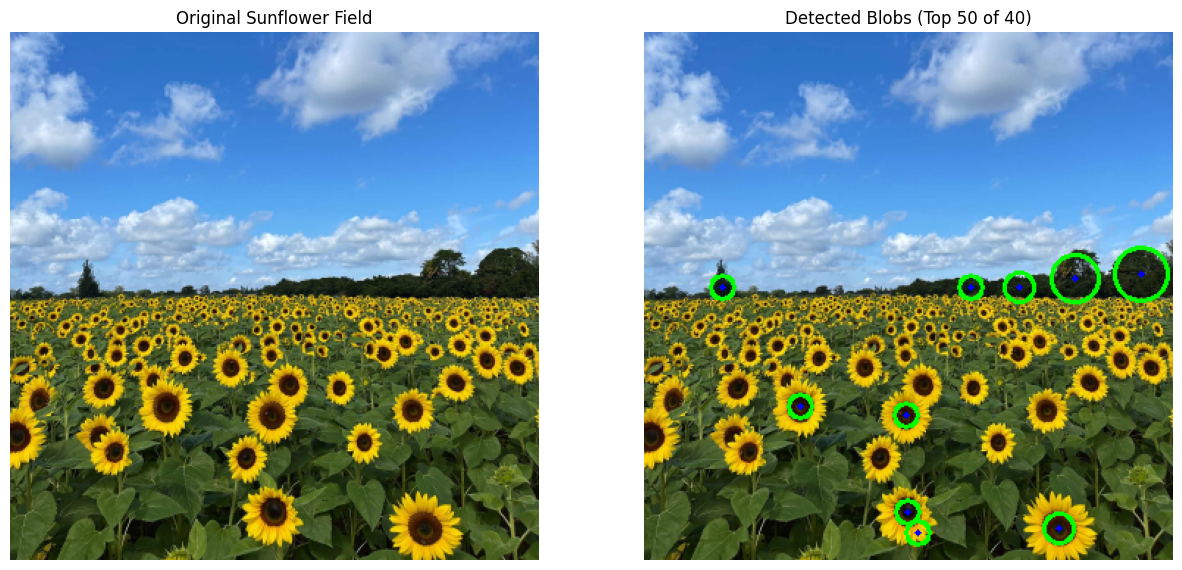

In [234]:
# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Original image
axes[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
axes[0].set_title('Original Sunflower Field')
axes[0].axis('off')

# Image with detected circles
result = img.copy()
for y, x, sigma, radius, response in largest_blobs[:10]:  # Draw top 10
    # Draw circle
    cv.circle(result, (int(x), int(y)), int(radius), (0, 255, 0), 2)
    # Draw center point
    cv.circle(result, (int(x), int(y)), 2, (255, 0, 0), -1)

axes[1].imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
axes[1].set_title(f'Detected Blobs (Top 50 of {len(filtered_blobs)})')
axes[1].axis('off')

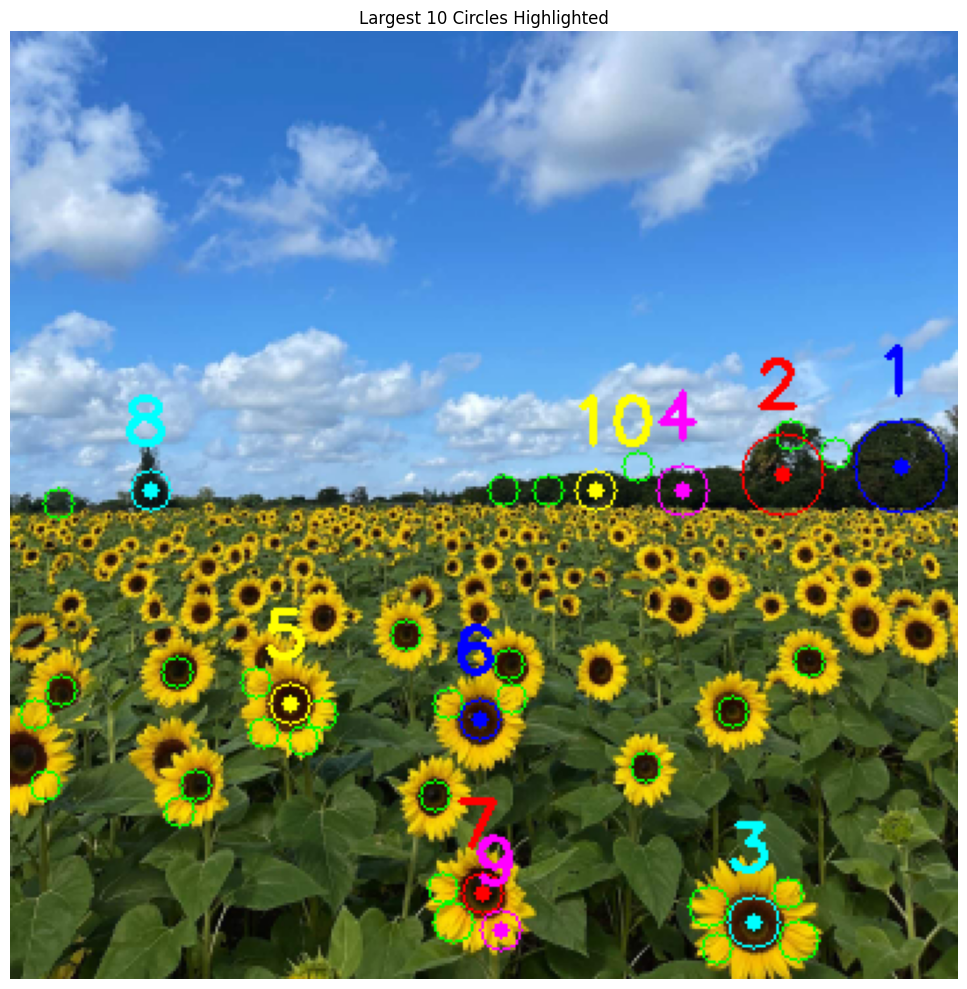

In [235]:

# Create detailed view of largest circles
fig2, ax = plt.subplots(1, 1, figsize=(12, 10))
result_large = img.copy()

# Draw all circles in green (thin)
for y, x, sigma, radius, response in filtered_blobs:
    cv.circle(result_large, (int(x), int(y)), int(radius), (0, 255, 0), 1)

# Highlight largest circles in different colors
colors = [(255, 0, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255), (0, 255, 255)]
for i, (y, x, sigma, radius, response) in enumerate(largest_blobs):
    color = colors[i % len(colors)]
    cv.circle(result_large, (int(x), int(y)), int(radius), color, 1)
    cv.circle(result_large, (int(x), int(y)), 3, color, -1)
    # Add label
    label = f"{i+1}"
    cv.putText(result_large, label, (int(x)-10, int(y)-int(radius)-10),
               cv.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

ax.imshow(cv.cvtColor(result_large, cv.COLOR_BGR2RGB))
ax.set_title(f'Largest {top_n} Circles Highlighted')
ax.axis('off')
plt.tight_layout()
plt.savefig('sunflower_largest_circles.png', dpi=150, bbox_inches='tight')
plt.show()
